# 03 — Object Tracking

This notebook covers:
- Overview of tracking algorithms
- DeepSORT tracker integration
- Fallback IoU tracker
- Trajectory visualisation
- Speed estimation demo
- Testing on a short video clip

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from src.detection  import YOLODetector
from src.tracking   import build_tracker, TrajectoryStore, IoUTracker
from src.utils      import SpeedEstimator, draw_box, get_logger

logger = get_logger("nb03")
print("Modules imported ✓")

Modules imported ✓


## 3.1  Tracker Comparison

| Tracker | Pros | Cons |
|---------|------|------|
| **DeepSORT** | Appearance re-ID, handles occlusion well | Needs GPU for embedder, extra install |
| **ByteTrack** | Fast, handles low-conf detections | Less robust re-ID |
| **IoU Tracker** | Zero extra dependencies, fast | Loses ID on occlusion |

We default to **DeepSORT** with IoU fallback.

In [2]:
import os
WEIGHTS = r"C:\Users\Lenovo\runs\detect\train3\weights\best.pt"

if not os.path.exists(WEIGHTS):
    WEIGHTS = "yolov8n.pt"
    print(f"Custom weights not found — using {WEIGHTS}")

detector = YOLODetector(weights=WEIGHTS, conf=0.35, device="cpu")
# Try DeepSORT; fall back to IoU automatically
tracker  = build_tracker(method="deepsort", max_age=30, n_init=3)
traj     = TrajectoryStore(maxlen=60)
speed_est = SpeedEstimator(fps=30.0, pixels_per_meter=8.0)

print("Detector:", type(detector).__name__)
print("Tracker :", type(tracker).__name__)

[08:11:03] INFO [tvd.detection] Loading YOLO model: C:\Users\Lenovo\runs\detect\train3\weights\best.pt on device=cpu
[08:11:04] INFO [tvd.detection] Model loaded successfully.
[08:11:22] INFO [tvd.tracking] DeepSORT tracker initialised.


Detector: YOLODetector
Tracker : DeepSORTTracker


## 3.2  Process a Short Video Clip

In [3]:
VIDEO_PATH = r"D:\e-challan-system\data\input\video3.mp4"  # replace with actual path

def process_clip(video_path: str, max_frames: int = 150):
    """
    Run detection + tracking on the first max_frames of a video.
    Returns annotated frames and trajectory data.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠  Could not open: {video_path}")
        print("  → Using synthetic demo frames instead.")
        return _demo_frames()

    fps    = cap.get(cv2.CAP_PROP_FPS) or 30
    frames = []
    frame_no = 0

    while frame_no < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        detections = detector.detect(frame)
        detections = tracker.update(detections, frame)

        for det in detections:
            if det.track_id == -1:
                continue
            traj.update(det.track_id, frame_no, det.center)
            speed = speed_est.update(det.track_id, frame_no, det.center)

            label = f"#{det.track_id} {det.class_name}"
            if speed and speed > 1.0:
                label += f" {speed:.0f}km/h"
            draw_box(frame, det.box, label,
                     color=(0, 255, 0) if det.group == "vehicle" else (255, 120, 0))

        frames.append(frame.copy())
        frame_no += 1

    cap.release()
    print(f"Processed {frame_no} frames.")
    return frames

def _demo_frames():
    """Generate synthetic annotated frames for demonstration."""
    frames = []
    for i in range(30):
        f = np.zeros((480, 640, 3), dtype=np.uint8)
        cv2.putText(f, f"Demo Frame {i+1}", (200, 240),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (100, 200, 100), 2)
        frames.append(f)
    return frames

frames = process_clip(VIDEO_PATH)
print(f"Total frames collected: {len(frames)}")

Processed 150 frames.
Total frames collected: 150


## 3.3  Visualise Tracked Frames

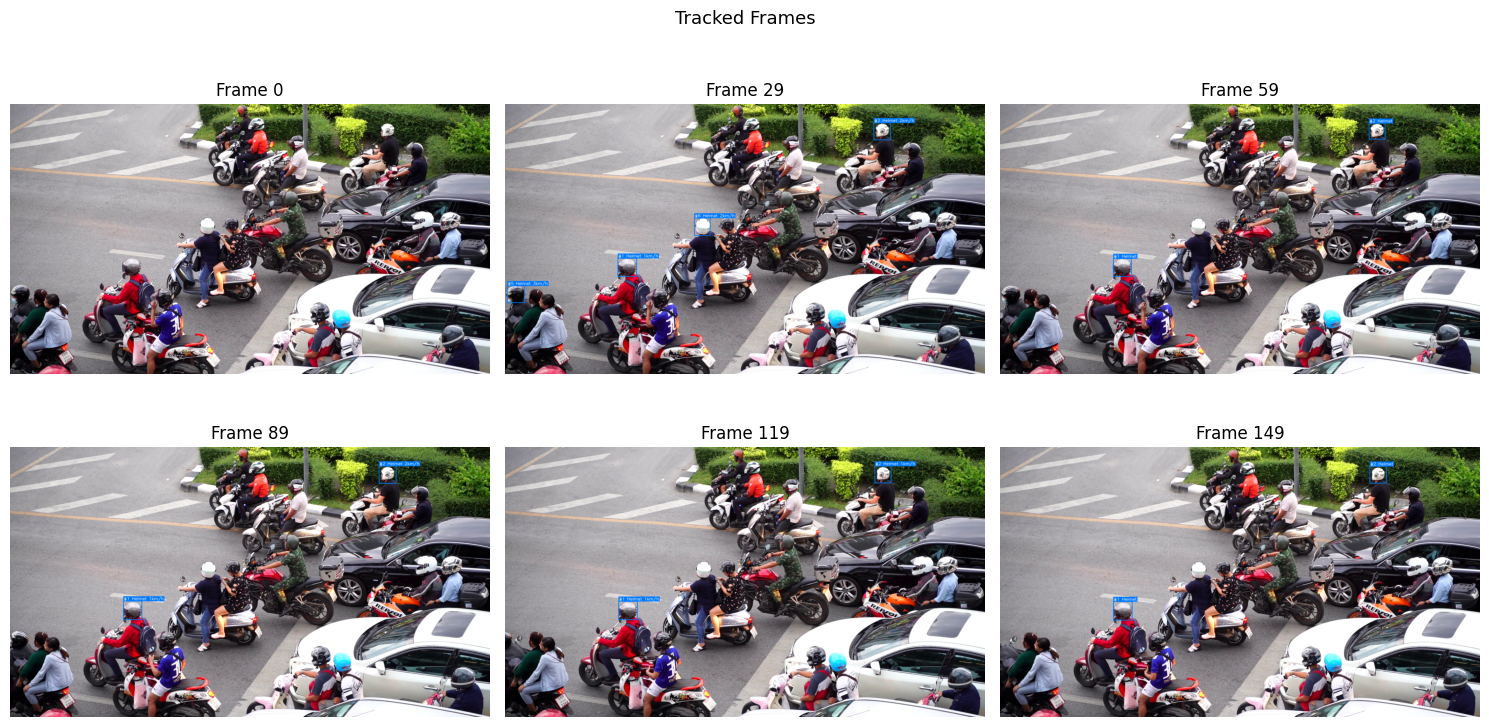

In [4]:
def show_frames_grid(frames, n=6, title="Tracked Frames"):
    """Show a grid of n evenly-spaced frames."""
    if not frames:
        print("No frames to show.")
        return
    indices = np.linspace(0, len(frames)-1, n, dtype=int)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, idx in zip(axes.flat, indices):
        rgb = cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        ax.set_title(f"Frame {idx}")
        ax.axis("off")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_frames_grid(frames)

## 3.4  Trajectory Visualisation

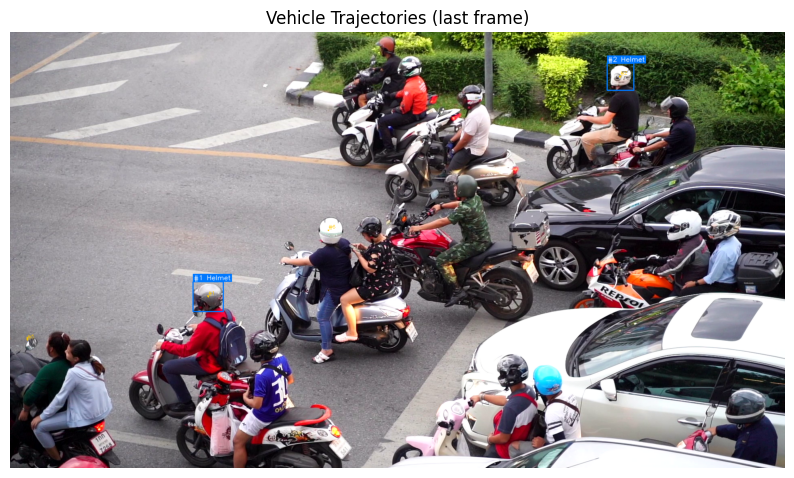

In [5]:
def draw_trajectories(frames, traj_store: TrajectoryStore,
                       color=(0, 200, 255), thickness=2):
    """Overlay trajectory paths on frames."""
    if not frames:
        return frames
    canvas = frames[-1].copy()
    for tid, history in traj_store._store.items():
        pts = [p for _, p in history]
        for i in range(1, len(pts)):
            p1 = (int(pts[i-1][0]), int(pts[i-1][1]))
            p2 = (int(pts[i][0]),   int(pts[i][1]))
            cv2.line(canvas, p1, p2, color, thickness)
        if pts:
            cv2.putText(canvas, f"#{tid}", (int(pts[-1][0]), int(pts[-1][1])-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return canvas

traj_frame = draw_trajectories(frames, traj)
if traj_frame is not None:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(traj_frame, cv2.COLOR_BGR2RGB))
    plt.title("Vehicle Trajectories (last frame)")
    plt.axis("off")
    plt.show()

## 3.5  Speed Distribution

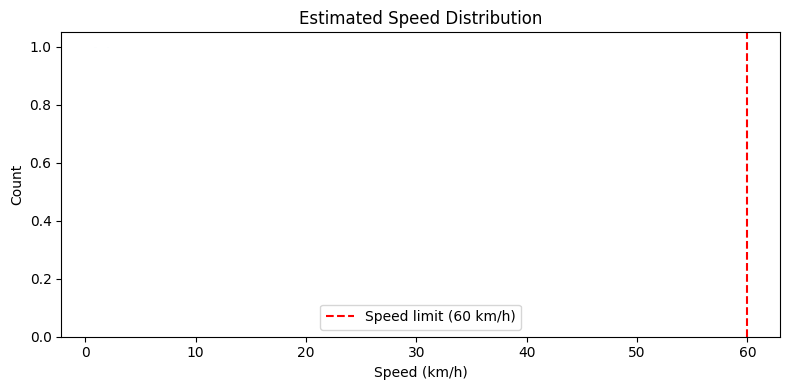

Mean speed: 1.2 km/h  |  Max: 2.1 km/h


In [6]:
speeds = list(speed_est.speeds.values())
if speeds:
    plt.figure(figsize=(8, 4))
    plt.hist(speeds, bins=20, color="steelblue", edgecolor="white")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Count")
    plt.title("Estimated Speed Distribution")
    plt.axvline(60, color="red", linestyle="--", label="Speed limit (60 km/h)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"Mean speed: {np.mean(speeds):.1f} km/h  |  Max: {max(speeds):.1f} km/h")
else:
    print("No speed data yet — run on a real video first.")

## 3.6  Stationarity Check (Parking detector preview)

In [7]:
print("Stationary vehicles (potential illegal parking):")
found = False
for tid in traj._store:
    if traj.is_stationary(tid, min_frames=30, pixel_threshold=12.0):
        print(f"  Track #{tid} — stationary")
        found = True
if not found:
    print("  None detected in this clip.")

Stationary vehicles (potential illegal parking):
  Track #1 — stationary
  Track #2 — stationary
  Track #5 — stationary


## ✅ Notebook 3 Summary

- Detector + DeepSORT/IoU tracker integrated
- Trajectory history maintained per track
- Speed estimated via pixel displacement
- Trajectory visualisation on final frame
- Speed distribution histogram
- Stationarity check for parking detection

**Next:** `04_violation_detection.ipynb`